In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

con = sqlite3.connect("nortestore_analytics_1.db")


revenue = pd.read_sql("SELECT * FROM rpt_revenue_mensual_categoria", con)
aov = pd.read_sql("SELECT * FROM rpt_aov_por_pais", con)
prod = pd.read_sql("SELECT * FROM rpt_top_productos_revenue_margen ", con)

prices = pd.read_sql("SELECT * FROM stg_products", con)


,product_id,product_name,category_clean,costo_estimado,unit_cost,unit_price,active
0,1,Auriculares,electronica,NO,25.19,52.08,1
1,2,Auriculares v2,electronica,NO,82.18,110.24,1
2,3,Smartwatch,electronica,NO,3.84,5.21,1
3,4,Parlante Bluetooth,electronica,NO,130.61,193.39,1
4,5,Parlante Bluetooth v2,electronica,NO,126.62,242.50,1


In [3]:
prod.head()

,product_name,revenue,pctMargin,margin
0,Difusor de aromas,39655.448,38.402058,15228.508
1,Mochila v2,35789.737,23.741435,8496.997
2,Hub USB v2,33802.560,48.069762,16248.810
3,Kit de skincare,33415.281,30.928009,10334.681
4,SSD externo v3,32819.516,25.593692,8399.726


In [27]:
aov.head()

,country,RevenuePromedio
0,argentina,954.685926
1,brasil,883.274766
2,chile,968.852574
3,colombia,945.331169
4,españa,884.966231


In [16]:
revenue.head()

,mes,category_clean,revenue
0,2024-06,belleza,12593.7130
1,2024-06,deportes,6724.2915
2,2024-06,electronica,18343.6815
3,2024-06,hogar,18340.5600
4,2024-06,indumentaria,13158.5055


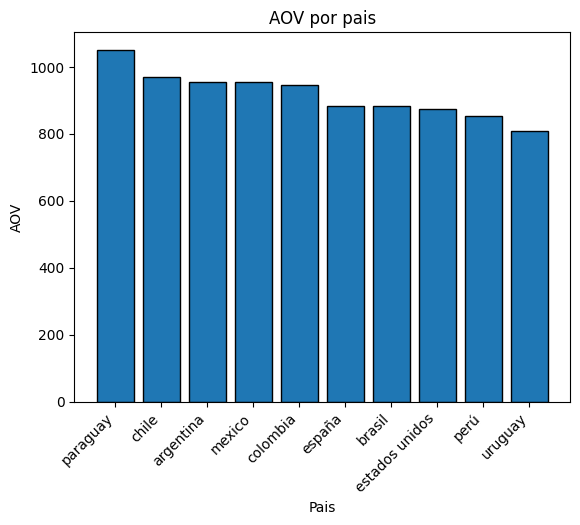

In [33]:
## revenue por pais

datos_ordenados = sorted(zip(aov["RevenuePromedio"], aov["country"]), reverse=True)
valores_ordenados, categorias_ordenadas = zip(*datos_ordenados)

plt.bar(categorias_ordenadas, valores_ordenados, width=0.8, bottom=None, align='center', data=None, edgecolor= "black")
plt.xticks(rotation = 45, ha= "right")

plt.xlabel("Pais")
plt.ylabel("AOV")
plt.title("AOV por pais")
plt.show()

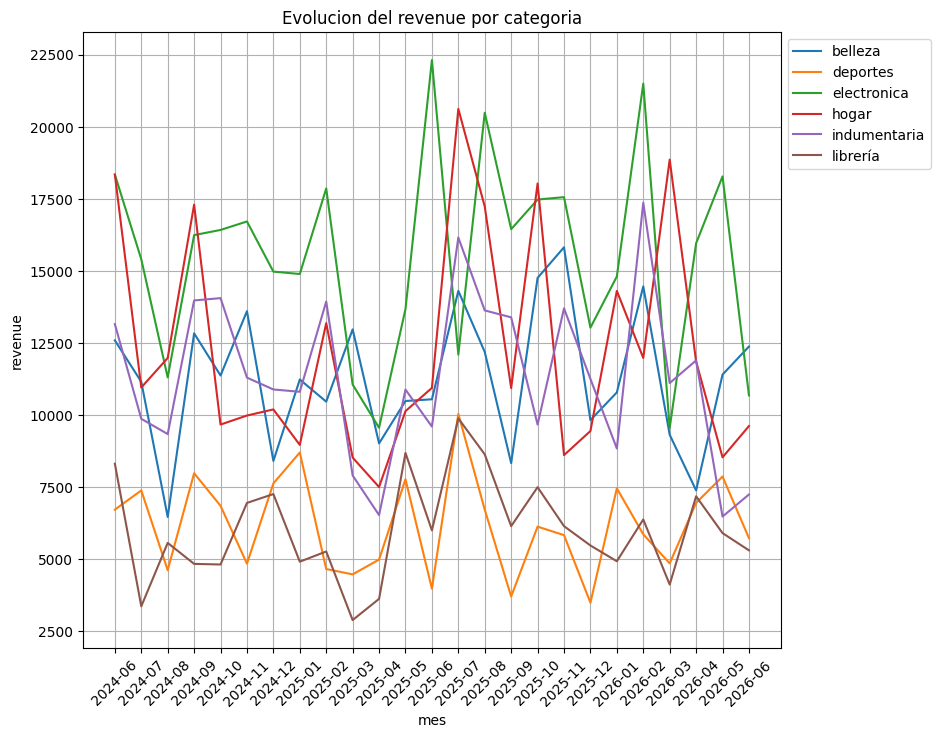

In [15]:
fig, ax = plt.subplots(figsize=(9, 8))
sns.lineplot(data=revenue, x='mes', y='revenue', hue='category_clean', ax = ax)

plt.title('Evolucion del revenue por categoria')
plt.grid(True)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation = 45)
plt.show()

In [20]:
top10 = prod[:10]

top10

,product_name,revenue,pctMargin,margin
0,Difusor de aromas,39655.448,38.402058,15228.508
1,Mochila v2,35789.737,23.741435,8496.997
2,Hub USB v2,33802.560,48.069762,16248.810
3,Kit de skincare,33415.281,30.928009,10334.681
4,SSD externo v3,32819.516,25.593692,8399.726
5,Power bank v3,30408.607,42.873082,13037.107
6,Perfume 50ml v2,30365.088,52.652994,15988.128
7,Plancha de cabello v2,29782.641,27.646611,8233.891
8,Agenda 2026,29533.401,23.836405,7039.701
9,Jean recto v2,28156.176,39.653559,11164.926


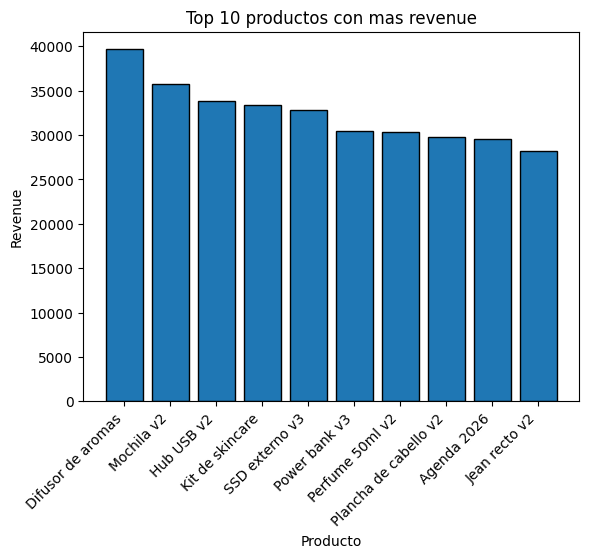

In [22]:

plt.bar(top10["product_name"], top10["revenue"], width=0.8, bottom=None, align='center', data=None, edgecolor= "black")
plt.xticks(rotation = 45, ha= "right")

plt.xlabel("Producto")
plt.ylabel("Revenue")
plt.title("Top 10 productos con mas revenue")
plt.show()

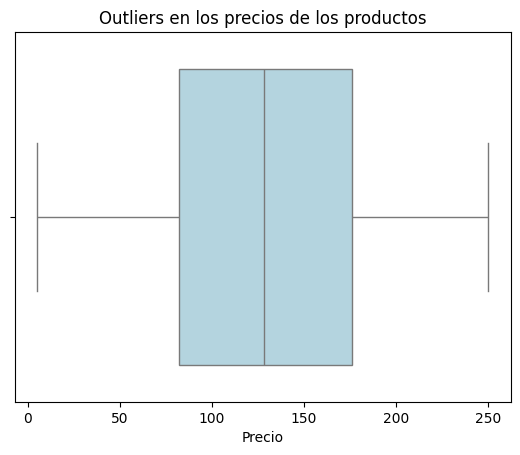

In [20]:
## Outliers


Q3 = np.percentile(prices["unit_price"],75)
Q1 = np.percentile(prices["unit_price"], 25)

IQR = Q3 - Q1

inf = Q1 - 1.5*IQR
sup = Q3 + 1.5*IQR


outliers = prices[(prices["unit_price"] > sup) | (prices["unit_price"] < inf)]

sns.boxplot(x=prices["unit_price"], color="lightblue", fliersize=0)
sns.stripplot(x=outliers["unit_price"], color="red", size=6, jitter=0.1, alpha=0.7)

plt.title('Outliers en los precios de los productos')
plt.xlabel("Precio")
plt.show()